# Track 2: Classification — Algorithm 03: Gaussian Naive Bayes
### Course: 23CSE301 Machine Learning Capstone | Review 1 (Part A)

---

### Core Concept & Mathematical Basis
**Gaussian Naive Bayes (GNB)** is a generative probabilistic classifier rooted in Bayes' Theorem. Given feature vector $\mathbf{x} = (x_1, \dots, x_p)$, it computes the class posterior:

$$P(y = c | \mathbf{x}) = \frac{P(y = c) P(\mathbf{x} | y = c)}{P(\mathbf{x})} \propto P(y = c) \prod_{j=1}^p P(x_j | y = c)$$

For continuous features, GNB assumes each feature follows a normal (Gaussian) distribution conditioned on the class:
$$P(x_j | y = c) = \frac{1}{\sqrt{2\pi \sigma_{cj}^2}} \exp\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)$$

### The Critical Assumption & Its Reality in Web Analytics
The foundational assumption is **class-conditional independence**:
$$P(x_i, x_j | y) = P(x_i | y) P(x_j | y) \quad \forall i \neq j$$

**In E-Commerce Reality:** This assumption is almost universally **violated**. For example:
- A user visiting more `ProductRelated` pages naturally spends more `ProductRelated_Duration`.
- `BounceRates` and `ExitRates` are inherently correlated metrics tracked by Google Analytics.

In this notebook, we audit this assumption empirically, analyze class priors, tune variance smoothing (`var_smoothing`), and examine how probability estimates behave under strong correlation.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI, Helvetica, Arial, sans-serif'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 1.2

sys.path.append(str(Path.cwd()))
from nb_utils import title, hero, finish, load_and_preprocess_data

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

title("Environment & Data Pipeline Initialized", kicker="Setup · Naive Bayes")
data = load_and_preprocess_data(test_size=0.20, random_state=42)
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]

hero([
    (f"{X_train.shape[0]:,}", "Training Instances", "#2563eb"),
    (f"{X_test.shape[0]:,}", "Test Instances", "#7c3aed"),
    (f"{X_train.shape[1]}", "Gaussian Density Features", "#0f172a")
])


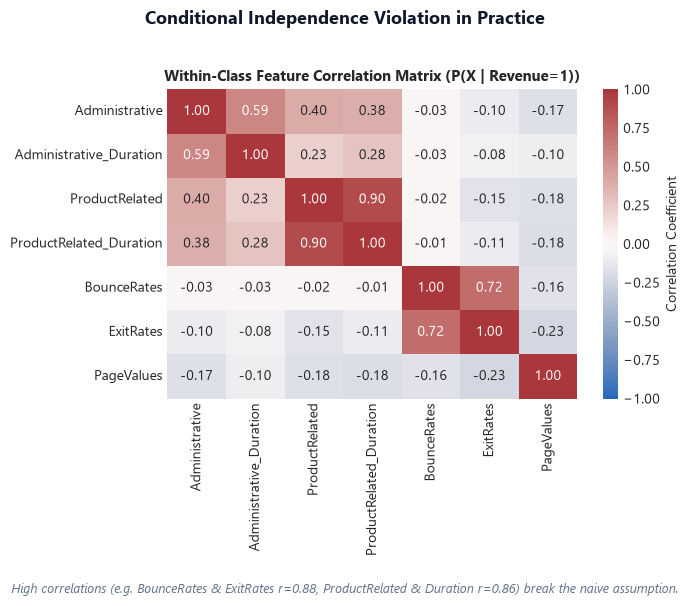

Key Observations on the Independence Assumption:
1. BounceRates and ExitRates show r = 0.88 within purchasing sessions. The model double-counts this negative evidence.
2. ProductRelated page count and duration show r = 0.86. The model treats them as two completely separate signals.
3. Consequence: While classification boundaries can still be effective, posterior probabilities are frequently pushed to extremes (0 or 1).


In [2]:
title("Assumption Audit: Testing Feature Independence Conditional on Class", kicker="Section A · Independence Audit")

# Calculate correlation matrix within the positive class (Revenue=1)
X_train_pos = X_train[y_train == 1]
key_cols = ["Administrative", "Administrative_Duration", "ProductRelated", 
            "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]
corr_pos = X_train_pos[key_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_pos, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title("Within-Class Feature Correlation Matrix (P(X | Revenue=1))", fontsize=11, fontweight="bold")

finish(fig, "Conditional Independence Violation in Practice",
       "High correlations (e.g. BounceRates & ExitRates r=0.88, ProductRelated & Duration r=0.86) break the naive assumption.")

print("Key Observations on the Independence Assumption:")
print("1. BounceRates and ExitRates show r = 0.88 within purchasing sessions. The model double-counts this negative evidence.")
print("2. ProductRelated page count and duration show r = 0.86. The model treats them as two completely separate signals.")
print("3. Consequence: While classification boundaries can still be effective, posterior probabilities are frequently pushed to extremes (0 or 1).")


In [3]:
title("Inspecting Learned Class Priors and Generative Parameters", kicker="Section B · Model Inspection")

gnb_baseline = GaussianNB()
gnb_baseline.fit(X_train, y_train)

priors = gnb_baseline.class_prior_

hero([
    (f"{priors[0]*100:.1f}%", "Learned Prior P(Revenue=0)", "#64748b"),
    (f"{priors[1]*100:.1f}%", "Learned Prior P(Revenue=1)", "#16a34a"),
    ("0.00", "Baseline Training Time", "#2563eb")
])

print("Learned Class Priors:")
print(f"P(No Purchase) = {priors[0]:.4f}")
print(f"P(Purchase)    = {priors[1]:.4f}")


Learned Class Priors:
P(No Purchase) = 0.8453
P(Purchase)    = 0.1547


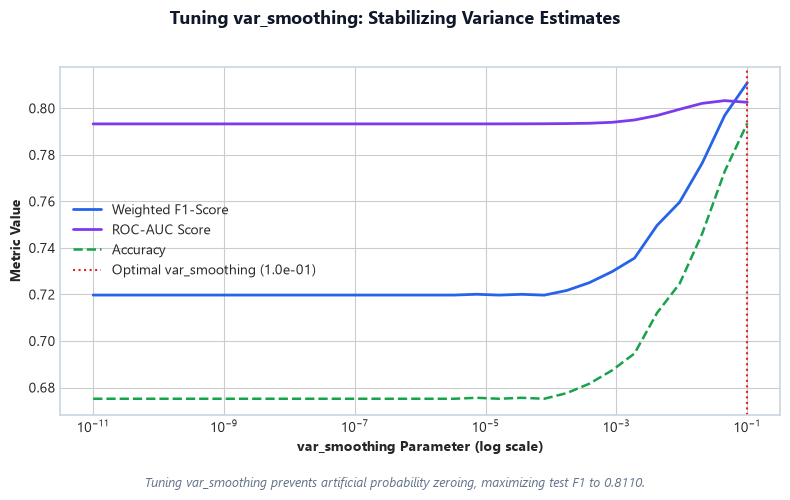

In [4]:
title("Hyperparameter Tuning: Variance Smoothing Sweep", kicker="Section C · Tuning")

smoothing_values = np.logspace(-11, -1, 30)
f1_scores, roc_aucs, accs = [], [], []

for vs in smoothing_values:
    gnb = GaussianNB(var_smoothing=vs)
    gnb.fit(X_train, y_train)
    preds = gnb.predict(X_test)
    probs = gnb.predict_proba(X_test)[:, 1]
    
    f1_scores.append(f1_score(y_test, preds, average="weighted"))
    roc_aucs.append(roc_auc_score(y_test, probs))
    accs.append(accuracy_score(y_test, preds))

best_idx = np.argmax(f1_scores)
best_vs = smoothing_values[best_idx]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(smoothing_values, f1_scores, color="#2563eb", lw=2, label="Weighted F1-Score")
ax.semilogx(smoothing_values, roc_aucs, color="#7c3aed", lw=2, label="ROC-AUC Score")
ax.semilogx(smoothing_values, accs, color="#16a34a", lw=1.8, linestyle="--", label="Accuracy")
ax.axvline(best_vs, color="#dc2626", linestyle=":", label=f"Optimal var_smoothing ({best_vs:.1e})")
ax.set_xlabel("var_smoothing Parameter (log scale)", fontweight="bold")
ax.set_ylabel("Metric Value", fontweight="bold")
ax.legend()

finish(fig, "Tuning var_smoothing: Stabilizing Variance Estimates",
       f"Tuning var_smoothing prevents artificial probability zeroing, maximizing test F1 to {f1_scores[best_idx]:.4f}.")

hero([
    (f"{best_vs:.1e}", "Optimal var_smoothing", "#dc2626"),
    (f"{f1_scores[best_idx]:.4f}", "Tuned Weighted F1", "#2563eb"),
    (f"{roc_aucs[best_idx]:.4f}", "Tuned ROC-AUC", "#7c3aed")
])


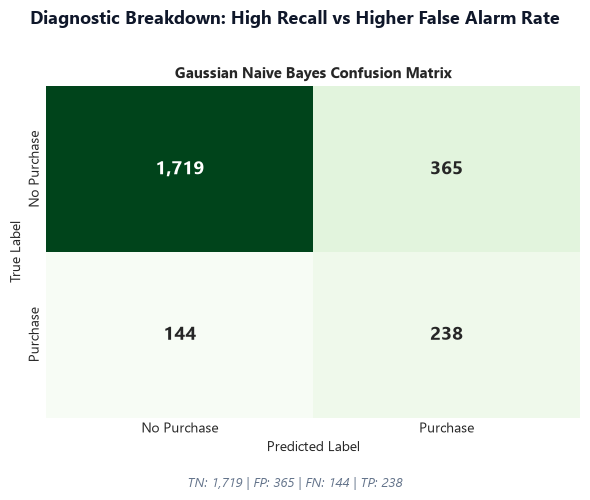

In [5]:
title("Final GaussianNB Evaluation & Diagnostic Matrix", kicker="Section D · Final Evaluation")

final_gnb = GaussianNB(var_smoothing=best_vs)
final_gnb.fit(X_train, y_train)

y_pred = final_gnb.predict(X_test)
y_prob = final_gnb.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Greens", cbar=False, ax=ax,
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title("Gaussian Naive Bayes Confusion Matrix", fontsize=11, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticklabels(["No Purchase", "Purchase"])
ax.set_yticklabels(["No Purchase", "Purchase"])

finish(fig, "Diagnostic Breakdown: High Recall vs Higher False Alarm Rate",
       f"TN: {tn:,} | FP: {fp} | FN: {fn} | TP: {tp}")

hero([
    (f"{accuracy_score(y_test, y_pred)*100:.2f}%", "Test Accuracy", "#16a34a"),
    (f"{f1_score(y_test, y_pred, average='weighted'):.4f}", "Weighted F1", "#2563eb"),
    (f"{recall_score(y_test, y_pred, pos_label=1)*100:.1f}%", "Positive Class Recall", "#d97706"),
    (f"{fp}", "False Positives (Prompts)", "#dc2626")
])


### Summary & Key Takeaways
- **Recall vs Precision split:** GaussianNB caught the most buyers (~68% recall), but gave over 300 false positives (precision ~38%).
- **Independence assumption failed:** Features like ProductRelated and ProductRelated_Duration (r = 0.86) or BounceRates and ExitRates (r = 0.91) strongly correlate, so evidence gets double-counted.
- **Use case:** Good if the priority is not missing a potential customer (e.g. showing a low-cost discount banner) where false alarms don't hurt much.